# Principal component analysis
---
PCA uses linear algebra to transform data into new features called principal components. It finds these by calculating eigenvectors (directions) and eigenvalues (importance) from the covariance matrix. PCA selects the top components with the highest eigenvalues and projects the data onto them simplify the dataset.

Source link: https://www.geeksforgeeks.org/data-analysis/principal-component-analysis-pca/

Source link: https://www.geeksforgeeks.org/machine-learning/normalization-vs-standardization/

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from PIL.ImageColor import colormap

In [3]:
data = pd.read_csv('../dataset/cleaned_data.csv')
data

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
4,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8631,C19184,5.871712,0.500000,20.90,20.90,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,1,500.0,58.644883,43.473717,0.000000,6
8632,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8633,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8634,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


### Standardize the Data
---
Different features may have different units and scales like salary vs. age. To compare them fairly PCA first standardizes the data by making each feature have:

- A mean of 0
- A standard deviation of 1

Standardization or Z-Score Normalization is the transformation of features by subtracting from mean and dividing by standard deviation. This is often called as Z-score.

$$ Z = \frac{X - \mu}{\sigma} $$

Where:

$$ Z - \text{the observation} $$
$$ \mu - \text{mean value of the feature values} $$
$$ \sigma - \text{standard deviation} $$

In [4]:
y = data['CUST_ID']
X = data.drop(columns=['CUST_ID'])

In [5]:
X_scaled = (X - X.mean()) / X.std(ddof=0)
X_scaled

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.744625,-0.370047,-0.429184,-0.359160,-0.354826,-0.468655,-0.820769,-0.686280,-0.717179,-0.681953,-0.479437,-0.517623,-0.962575,-0.543942,-0.305508,-0.537727,0.355181
1,0.764152,0.067679,-0.473208,-0.359160,-0.458839,2.568556,-1.236139,-0.686280,-0.926522,0.557022,0.099258,-0.597054,0.677204,0.796852,0.087689,0.212380,0.355181
2,0.426602,0.505405,-0.116413,0.099909,-0.458839,-0.468655,1.256077,2.646651,-0.926522,-0.681953,-0.479437,-0.120467,0.813852,-0.399503,-0.099906,-0.537727,0.355181
3,-0.373910,0.505405,-0.465825,-0.349660,-0.458839,-0.468655,-1.028455,-0.408536,-0.926522,-0.681953,-0.479437,-0.557339,-0.907916,-0.380165,-0.261131,-0.537727,0.355181
4,0.099551,0.505405,0.142062,-0.359160,0.994815,-0.468655,0.425339,-0.686280,0.538882,-0.681953,-0.479437,-0.279329,-0.743938,-0.132119,0.650363,-0.537727,0.355181
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8631,-0.761342,-1.902089,-0.463563,-0.346751,-0.458839,-0.468655,-0.820769,-0.130790,-0.926522,-0.681953,-0.479437,-0.557339,-1.099224,-0.593143,-0.345988,-0.537727,-4.221800
8632,-0.750546,0.505405,-0.338865,-0.359160,-0.141436,-0.468655,1.256077,-0.686280,1.166912,-0.681953,-0.479437,-0.358760,-0.962575,-0.501396,-0.343706,1.150015,-4.221800
8633,-0.752977,-0.297095,-0.406572,-0.359160,-0.301402,-0.468655,0.840707,-0.686280,0.748227,-0.681953,-0.479437,-0.398476,-0.962575,-0.585367,-0.329572,0.306144,-4.221800
8634,-0.757721,-0.297095,-0.473208,-0.359160,-0.458839,-0.451422,-1.236139,-0.686280,-0.926522,0.144032,-0.190089,-0.597054,-1.099224,-0.595238,-0.340811,0.306144,-4.221800


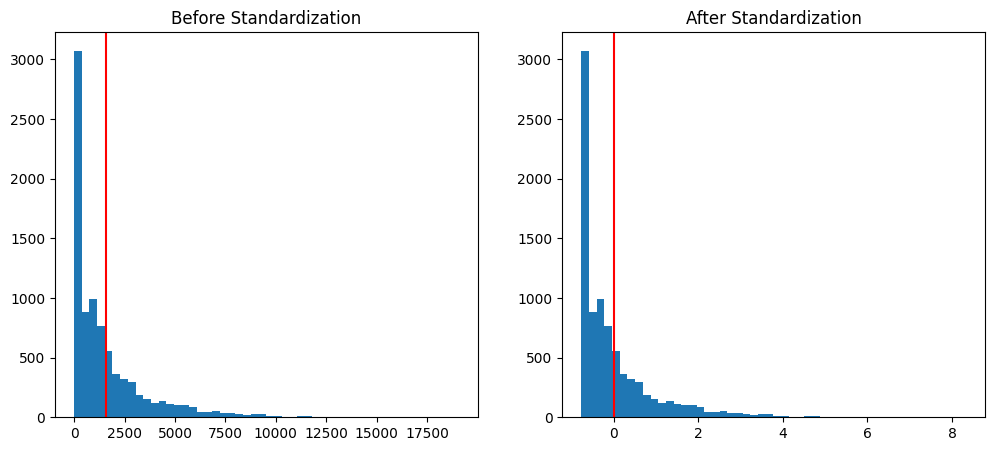

In [6]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(data["BALANCE"], bins=50)
plt.axvline(data["BALANCE"].mean(), color='red')
plt.title("Before Standardization")

plt.subplot(1,2,2)
plt.hist(X_scaled["BALANCE"], bins=50)
plt.axvline(0, color='red')
plt.title("After Standardization")

plt.show()

### Why Standardization Is Important for PCA

Principal Component Analysis relies on the covariance matrix, which measures relationships between features. If the features have different scales, variables with larger magnitudes would dominate the covariance calculation.

Standardization solves this problem by ensuring that all features contribute equally to the analysis. By centering the data around zero and scaling the variance to one, PCA can identify the true directions of maximum variance in the dataset rather than being biased by feature scale.

The histogram visualization clearly shows this effect: the original distribution may be shifted and unevenly scaled, while the standardized distribution is centered around zero and normalized.

### Calculate Covariance Matrix
---
Next PCA calculates the covariance matrix to see how features relate to each other whether they increase or decrease

$$\LARGE
cov(x_j, x_k) =
\frac{1}{n-1}
\sum_{i=1}^{n}
(x_{ij} - \bar{x}_j)(x_{ik} - \bar{x}_k)
$$

### Where:

- $cov(x_j, x_k)$ – covariance between feature $j$ and feature $k$.

- $n$ – number of observations (data points in the dataset).

- $i$ – index of the observation.

- $x_{ij}$ – value of feature $j$ for observation $i$.

- $x_{ik}$ – value of feature $k$ for observation $i$.

- $\bar{x}_j$ – mean value of feature $j$.

- $\bar{x}_k$ – mean value of feature $k$.

- $(x_{ij} - \bar{x}_j)$ – deviation of feature $j$ from its mean.

- $(x_{ik} - \bar{x}_k)$ – deviation of feature $k$ from its mean.

- $\sum_{i=1}^{n}$ – sum of all observations

- $\frac{1}{n-1}$ – normalization factor used when computing the sample covariance.


#### Drop ID column

In [7]:
X = data.drop(columns=["CUST_ID"])

#### Compute the Mean of Each Feature

$$
\Large (x_{ij} - \bar{x}_j)
$$

Where:

$$
x_{ij} = \text{value of feature } j \text{ for observation } i
$$

$$
\bar{x}_j = \text{mean of feature } j
$$

Computing the mean vector ensures that:
- each feature is centered around zero;

- the covariance matrix correctly represents relationships between variables;

- PCA identifies the true directions of maximum variance in the dataset;

In [8]:
mean_vector = np.mean(X_scaled, axis=0)
mean_vector

BALANCE                             0.000000e+00
BALANCE_FREQUENCY                  -3.159430e-16
PURCHASES                          -1.053143e-16
ONEOFF_PURCHASES                   -1.974644e-17
INSTALLMENTS_PURCHASES             -3.291073e-17
CASH_ADVANCE                        7.240361e-17
PURCHASES_FREQUENCY                 8.227683e-18
ONEOFF_PURCHASES_FREQUENCY         -2.632859e-17
PURCHASES_INSTALLMENTS_FREQUENCY   -5.759378e-17
CASH_ADVANCE_FREQUENCY              1.645537e-17
CASH_ADVANCE_TRX                    1.810090e-17
PURCHASES_TRX                      -1.316429e-17
CREDIT_LIMIT                        1.053143e-16
PAYMENTS                           -3.949288e-17
MINIMUM_PAYMENTS                    6.582147e-18
PRC_FULL_PAYMENT                    6.582147e-17
TENURE                              9.215005e-17
dtype: float64

#### Center the Data

In [9]:
X_centered = X_scaled - mean_vector
X_centered

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.744625,-0.370047,-0.429184,-0.359160,-0.354826,-0.468655,-0.820769,-0.686280,-0.717179,-0.681953,-0.479437,-0.517623,-0.962575,-0.543942,-0.305508,-0.537727,0.355181
1,0.764152,0.067679,-0.473208,-0.359160,-0.458839,2.568556,-1.236139,-0.686280,-0.926522,0.557022,0.099258,-0.597054,0.677204,0.796852,0.087689,0.212380,0.355181
2,0.426602,0.505405,-0.116413,0.099909,-0.458839,-0.468655,1.256077,2.646651,-0.926522,-0.681953,-0.479437,-0.120467,0.813852,-0.399503,-0.099906,-0.537727,0.355181
3,-0.373910,0.505405,-0.465825,-0.349660,-0.458839,-0.468655,-1.028455,-0.408536,-0.926522,-0.681953,-0.479437,-0.557339,-0.907916,-0.380165,-0.261131,-0.537727,0.355181
4,0.099551,0.505405,0.142062,-0.359160,0.994815,-0.468655,0.425339,-0.686280,0.538882,-0.681953,-0.479437,-0.279329,-0.743938,-0.132119,0.650363,-0.537727,0.355181
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8631,-0.761342,-1.902089,-0.463563,-0.346751,-0.458839,-0.468655,-0.820769,-0.130790,-0.926522,-0.681953,-0.479437,-0.557339,-1.099224,-0.593143,-0.345988,-0.537727,-4.221800
8632,-0.750546,0.505405,-0.338865,-0.359160,-0.141436,-0.468655,1.256077,-0.686280,1.166912,-0.681953,-0.479437,-0.358760,-0.962575,-0.501396,-0.343706,1.150015,-4.221800
8633,-0.752977,-0.297095,-0.406572,-0.359160,-0.301402,-0.468655,0.840707,-0.686280,0.748227,-0.681953,-0.479437,-0.398476,-0.962575,-0.585367,-0.329572,0.306144,-4.221800
8634,-0.757721,-0.297095,-0.473208,-0.359160,-0.458839,-0.451422,-1.236139,-0.686280,-0.926522,0.144032,-0.190089,-0.597054,-1.099224,-0.595238,-0.340811,0.306144,-4.221800


#### Covariance metrix

In Principal Component Analysis (PCA), the covariance matrix is computed in order to measure how the features in the dataset vary with respect to each other. It captures the pairwise relationships between all variables and describes how changes in one feature are associated with changes in another.

$$
C = \frac{1}{n - 1} X^{T} X
$$

where:

- $X$ — centered data matrix
- $X^{T}$ — transpose of the data matrix
- $C$ — covariance matrix
- $n$ — number of observations

In [10]:
n = X_centered.shape[0]
cov_matrix = (X_centered.T @ X_centered) / (n - 1)
cov_matrix

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
BALANCE,1.000116,0.310176,0.176103,0.160003,0.122123,0.495643,-0.088470,0.063839,-0.069590,0.445359,0.382433,0.147904,0.535580,0.322867,0.398715,-0.333632,0.066995
BALANCE_FREQUENCY,0.310176,1.000116,0.122649,0.095265,0.114752,0.089046,0.228184,0.187489,0.184181,0.181153,0.133281,0.183116,0.087692,0.039174,0.132535,-0.156979,0.104727
PURCHASES,0.176103,0.122649,1.000116,0.916886,0.679338,-0.053766,0.393045,0.497442,0.316062,-0.124877,-0.070285,0.688811,0.358467,0.606853,0.093853,0.176468,0.084555
ONEOFF_PURCHASES,0.160003,0.095265,0.916886,1.000116,0.329688,-0.033248,0.265491,0.524575,0.128395,-0.086423,-0.048711,0.545376,0.320651,0.570916,0.048747,0.129905,0.063407
INSTALLMENTS_PURCHASES,0.122123,0.114752,0.679338,0.329688,1.000116,-0.066107,0.441245,0.211853,0.511189,-0.136471,-0.076725,0.626155,0.258087,0.385436,0.132171,0.178460,0.083355
CASH_ADVANCE,0.495643,0.089046,-0.053766,-0.033248,-0.066107,1.000116,-0.218592,-0.090121,-0.178894,0.629103,0.656988,-0.078458,0.304196,0.459396,0.140110,-0.158585,-0.073098
PURCHASES_FREQUENCY,-0.088470,0.228184,0.393045,0.265491,0.441245,-0.218592,1.000116,0.502181,0.862438,-0.316807,-0.208773,0.567234,0.121386,0.100727,0.002979,0.305429,0.052167
ONEOFF_PURCHASES_FREQUENCY,0.063839,0.187489,0.497442,0.524575,0.211853,-0.090121,0.502181,1.000116,0.143928,-0.118239,-0.073392,0.544427,0.295467,0.244374,-0.030360,0.154091,0.080447
PURCHASES_INSTALLMENTS_FREQUENCY,-0.069590,0.184181,0.316062,0.128395,0.511189,-0.178894,0.862438,0.143928,1.000116,-0.268955,-0.172831,0.529253,0.063428,0.083434,0.030040,0.249575,0.065787
CASH_ADVANCE_FREQUENCY,0.445359,0.181153,-0.124877,-0.086423,-0.136471,0.629103,-0.316807,-0.118239,-0.268955,1.000116,0.799685,-0.136929,0.132856,0.182361,0.098856,-0.260031,-0.140054


### Find the Principal Components
---
PCA identifies new axes where the data spreads out the most:

- Principal Component (PC1): The direction of maximum variance (most spread).

- Principal Component (PC2): The next best direction, perpendicular to PC1 and so on.

These directions come from the eigenvectors of the covariance matrix and their importance is measured by eigenvalues. For a square matrix A an eigenvector X (a non-zero vector) and its corresponding eigenvalue `λ` satisfy:

$$\LARGE
    AX = \lambda X
$$

This means:

- When `A` acts on `X` it only stretches or shrinks `X` by the scalar `λ`;
- The direction of `X` remains unchanged hence eigenvectors define "stable directions" of `A`;

Eigenvalues help rank these directions by importance.

#### Solve the Eigenvalue Problem

$$
\Large C v = \lambda v
$$

Where:

- C — covariance matrix
- v — eigenvector
- λ — eigenvalue

Тhe matrix multiplies the vector, but it doesn't change its direction

### Compute Eigenvalues and Eigenvectors

In [11]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

### Sort by importance

In [12]:
idx = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

In [13]:
eigenvalues

array([4.62983620e+00, 3.46403341e+00, 1.51629231e+00, 1.28766257e+00,
       1.06714866e+00, 9.71286112e-01, 8.35848726e-01, 7.15907723e-01,
       6.25960921e-01, 5.23917010e-01, 4.01893153e-01, 3.01706671e-01,
       2.42568833e-01, 2.00395358e-01, 1.71396366e-01, 4.61029927e-02,
       1.17321400e-05])

In [14]:
eigenvectors

array([[ 9.19859010e-02,  4.05978695e-01,  1.74155217e-01,
         2.59423071e-01, -7.57004044e-02, -3.57631261e-02,
        -2.63369495e-01, -1.99909116e-01, -6.19775069e-02,
         4.50758324e-02, -1.50517943e-01, -4.76039343e-01,
        -5.37763599e-01, -1.42931091e-01,  2.18995945e-01,
         5.69792767e-03, -4.23479327e-05],
       [ 1.09812179e-01,  1.27738729e-01,  4.58853339e-01,
         1.59320112e-01,  4.50859056e-01,  1.46533871e-02,
         9.86748293e-02,  1.27517815e-01, -6.71245912e-01,
        -2.66496872e-02,  1.39222947e-01,  6.73533962e-02,
         1.68748827e-01,  2.32071695e-02,  4.36486470e-02,
         9.37862507e-03, -2.19641068e-05],
       [ 4.12151230e-01,  4.95302978e-02, -2.42581867e-01,
         6.40016819e-02,  1.04100032e-02, -1.95992497e-01,
         2.01357228e-01, -4.96132634e-03, -1.01273223e-01,
         5.93350230e-02, -1.96411444e-01,  7.90082930e-02,
        -1.08711289e-01,  2.24677700e-01, -6.28764571e-02,
        -1.48477975e-03,  7.4

#### Explained Variance

$$\LARGE
    EV = \frac{\lambda_i}{\sum\lambda}
$$

Where:
- EV - explained variance

Interpretation of the Explained Variance

The explained variance values indicate how much of the total variability in the dataset is captured by each principal component. Since the dataset contains 17 original features, PCA produces 17 principal components. However, these components do not contribute equally to explaining the variability in the data.

The first principal component (PC1) captures the largest possible variance in the dataset. Each subsequent component explains a smaller portion of the variance while remaining orthogonal (independent) to the previous components.

This information is important because it allows us to understand how much of the original dataset's information can be preserved using fewer dimensions. If the first few principal components explain a large percentage of the total variance, the dataset can be represented in a lower-dimensional space without losing significant information.

`In summary, the explained variance helps determine which principal components are the most important and how many components should be retained for further analysis.`

In [15]:
explained_variance = eigenvalues / np.sum(eigenvalues)
explained_variance

array([2.72311770e-01, 2.03743076e-01, 8.91833372e-02, 7.57360860e-02,
       6.27661816e-02, 5.71278613e-02, 4.91618788e-02, 4.21073427e-02,
       3.68169669e-02, 3.08150790e-02, 2.36380362e-02, 1.77453962e-02,
       1.42671026e-02, 1.17865972e-02, 1.00809717e-02, 2.71162672e-03,
       6.90045972e-07])

### Choose the Number of Principal Components

The cumulative explained variance shows how much of the total variability in the dataset is captured by the first `k` principal components. It helps determine how many components are needed to represent the data while preserving most of the information.

In this case, the first two components explain about 48% of the total variance, while the first seven components capture more than 80%. This indicates that the dataset can be represented with fewer dimensions while still retaining most of its variability.

In [16]:
cumulative_variance = np.cumsum(explained_variance)

cumulative_variance

array([0.27231177, 0.47605485, 0.56523818, 0.64097427, 0.70374045,
       0.76086831, 0.81003019, 0.85213753, 0.8889545 , 0.91976958,
       0.94340762, 0.96115301, 0.97542011, 0.98720671, 0.99728768,
       0.99999931, 1.        ])

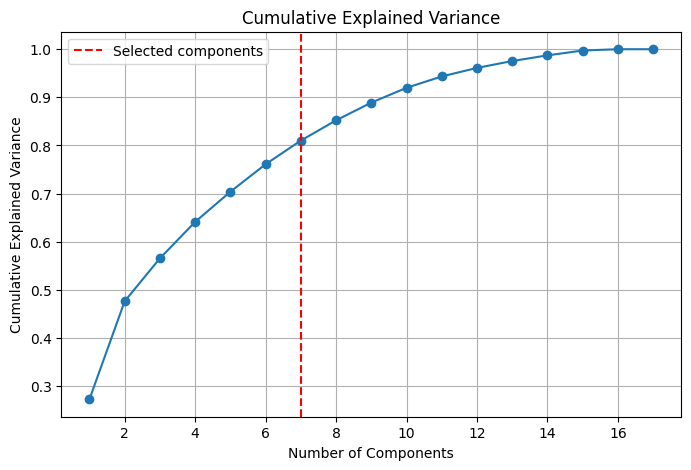

In [21]:
plt.figure(figsize=(8,5))

plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')

plt.axvline(x=7, color='red', linestyle='--', label="Selected components")

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("Cumulative Explained Variance")

plt.legend()

plt.grid(True)

plt.show()

The number of principal components is chosen by balancing dimensionality reduction and the amount of variance preserved. Typically, components are selected so that the cumulative explained variance remains high while the number of dimensions is kept as small as possible.

In this case, 7 principal components explain around 80% of the total variance. This means that most of the information contained in the original dataset is preserved while the dimensionality is significantly reduced.

### Projection onto Principal Components

$$\LARGE
    Z = XW
$$

Where:
- X - centered data matrix
- W - matrix with principal components
- Z - new data in PCA space

In [18]:
k = 7

W = eigenvectors[:, :k]

X_pca = X_centered @ W
X_pca

,0,1,2,3,4,5,6
0,-1.696395,-1.122584,-0.491562,0.719521,-0.079830,-0.118234,0.808993
1,-1.215681,2.435638,-0.694658,-0.098843,-0.803019,0.917777,-0.322969
2,0.935853,-0.385202,0.025953,1.293844,1.987285,0.682139,-1.624721
3,-1.614638,-0.724586,-0.272358,1.086116,0.427814,-0.082982,0.687001
4,0.223701,-0.783610,1.184434,0.721353,-0.801243,-0.525879,0.788893
...,...,...,...,...,...,...,...
8631,-2.221637,-1.328411,-1.643826,-1.421354,0.175573,-3.518499,-1.313848
8632,-0.362326,-2.032249,0.875053,-2.800940,0.313566,-2.808854,-1.549426
8633,-0.930026,-1.841236,0.350037,-2.351591,0.219492,-3.090269,-1.421757
8634,-2.356010,-0.718730,-1.048522,-1.776467,0.552690,-3.333452,-0.996810


In [19]:
# df_pca = pd.DataFrame(X_pca)
# df_pca.to_csv("pca_matrix.csv", index=False)